In [2]:
# Step 1: Mount Google Drive to access images
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to display images
def display_image(image, title='Image'):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) if len(image.shape) == 3 else plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


Mounted at /content/drive


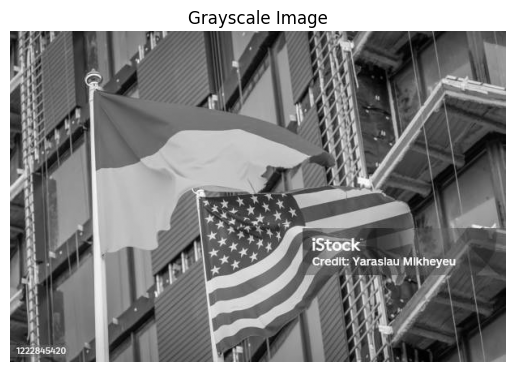

In [3]:
# Load the image
# Replace 'path/to/your/image.jpg' with your actual image path in Google Drive
image_path = '/content/task_12.jpg'
image = cv2.imread(image_path)

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
display_image(gray_image, title='Grayscale Image')

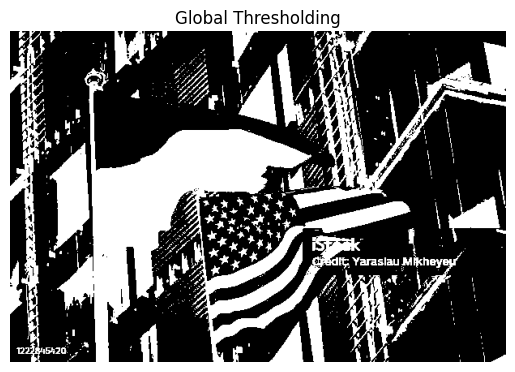

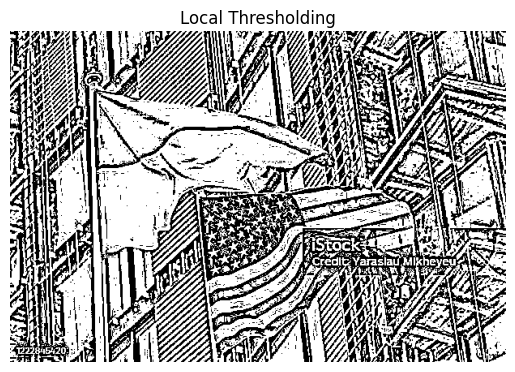

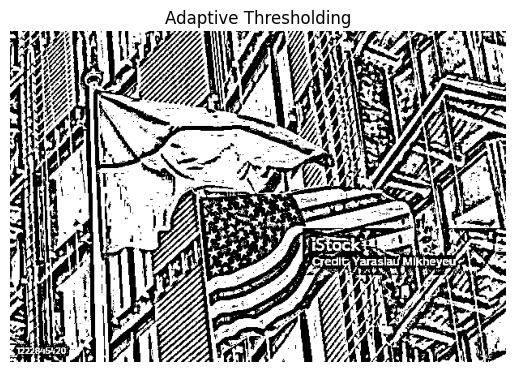

In [4]:
# Task 1: Global Thresholding
_, global_thresh = cv2.threshold(gray_image, 128, 255, cv2.THRESH_BINARY)
display_image(global_thresh, title='Global Thresholding')

# Task 1: Local Thresholding (using adaptive thresholding)
local_thresh = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)
display_image(local_thresh, title='Local Thresholding')

# Task 1: Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                         cv2.THRESH_BINARY, 11, 2)
display_image(adaptive_thresh, title='Adaptive Thresholding')

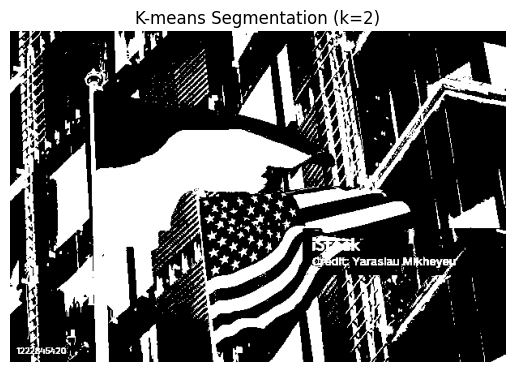

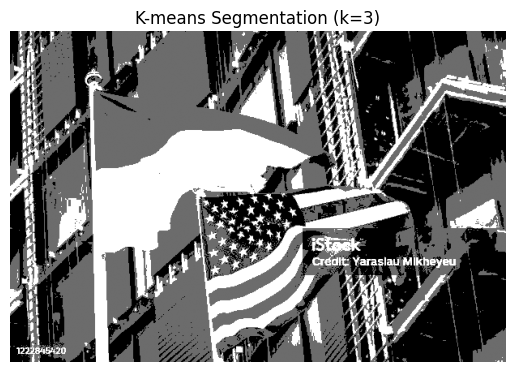

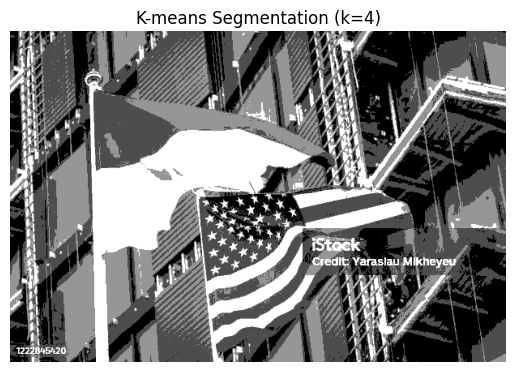

In [5]:
# Task 2: K-means Segmentation
def kmeans_segmentation(image, k):
    # Reshape the image to a 2D array of pixels
    pixel_values = image.reshape((-1, 1))
    pixel_values = np.float32(pixel_values)

    # Define criteria and apply k-means
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Convert back to uint8 and reshape to original image dimensions
    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    return segmented_image.reshape(image.shape)

# Perform K-means segmentation with k=2, k=3, k=4
for k in [2, 3, 4]:
    kmeans_result = kmeans_segmentation(gray_image, k)
    display_image(kmeans_result, title=f'K-means Segmentation (k={k})')


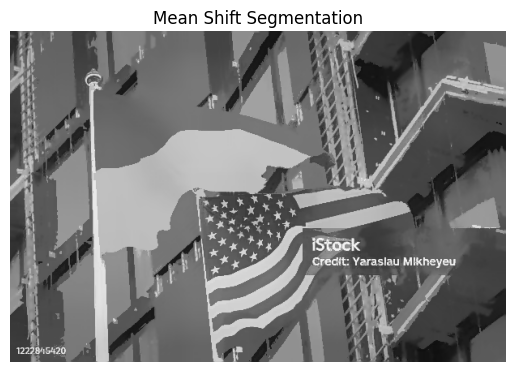

In [7]:
# Task 3: Mean Shift Segmentation
def mean_shift_segmentation(image):
    # Convert to a 2D array of pixel values
    pixel_values = image.reshape((-1, 1))
    pixel_values = np.float32(pixel_values)

    # Apply Mean Shift. The function expects a 3-channel image.
    # Convert the 1-channel grayscale image to a 3-channel BGR image.
    bgr_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    mean_shift = cv2.pyrMeanShiftFiltering(bgr_image, sp=21, sr=51)
    return mean_shift

mean_shift_result = mean_shift_segmentation(gray_image)
display_image(mean_shift_result, title='Mean Shift Segmentation')

In [8]:
# Task 4: Compare Results Visually
titles = ['Original Image', 'Global Thresholding', 'Local Thresholding',
          'Adaptive Thresholding', 'Mean Shift']
images = [image, global_thresh, local_thresh, adaptive_thresh, mean_shift_result]


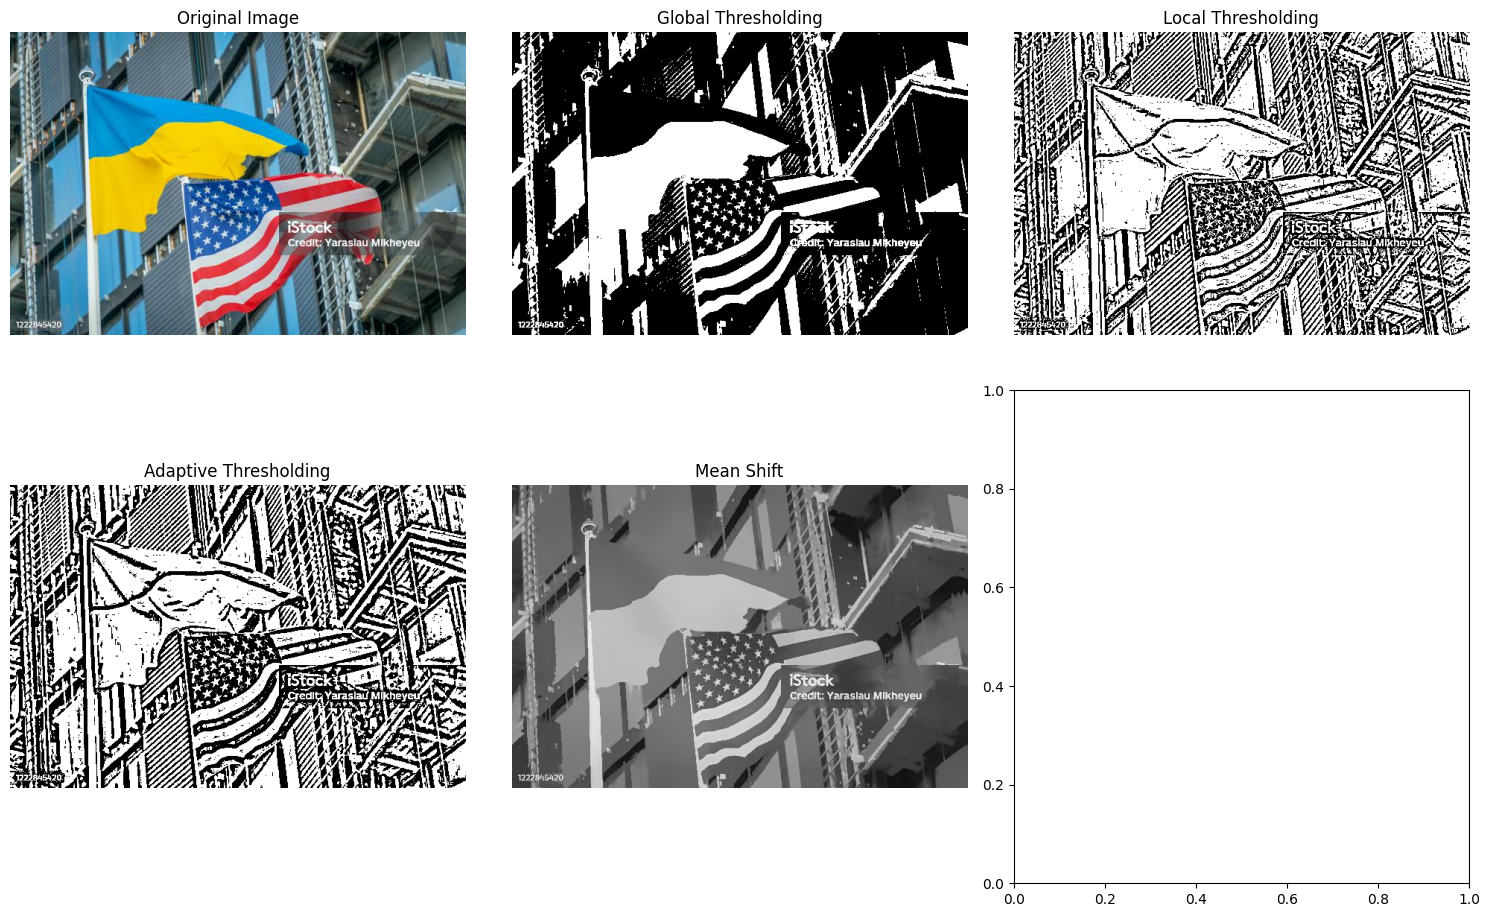

In [9]:
# Display comparisons
comparison_fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for ax, title, img in zip(axs.ravel(), titles, images):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape) == 3 else img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Task 5: Discuss Method Strengths
discussion = """
1. Global Thresholding:
   - Simple and effective for images with uniform lighting.

2. Local Thresholding:
   - Works well for varying illumination and highlights features better.

3. K-means Segmentation:
   - Clusters pixels based on color similarity, but sensitive to initialization.

4. Mean Shift Segmentation:
   - Non-parametric and does not require preprocessing, adapts to the pixel distribution.
"""

print(discussion)


1. Global Thresholding:
   - Simple and effective for images with uniform lighting.
   
2. Local Thresholding:
   - Works well for varying illumination and highlights features better.
   
3. K-means Segmentation:
   - Clusters pixels based on color similarity, but sensitive to initialization.
   
4. Mean Shift Segmentation:
   - Non-parametric and does not require preprocessing, adapts to the pixel distribution.



Task for another image

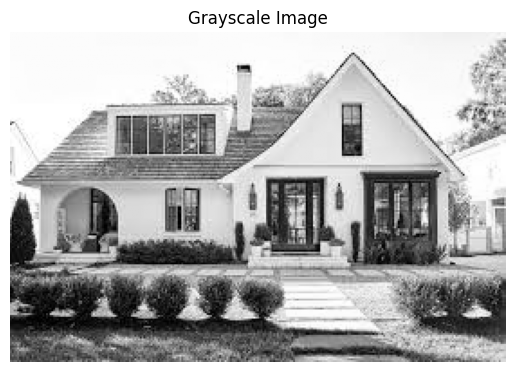

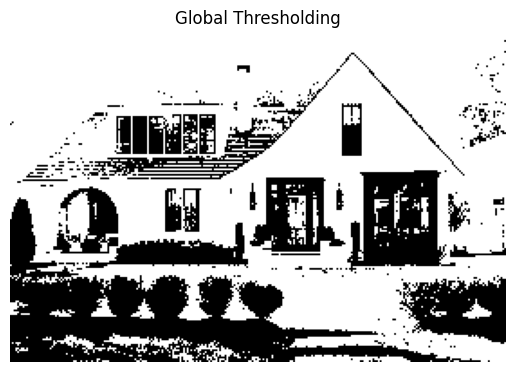

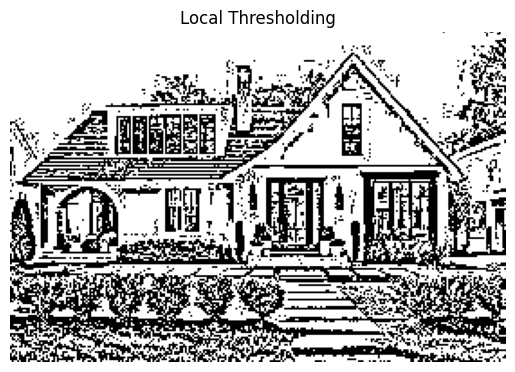

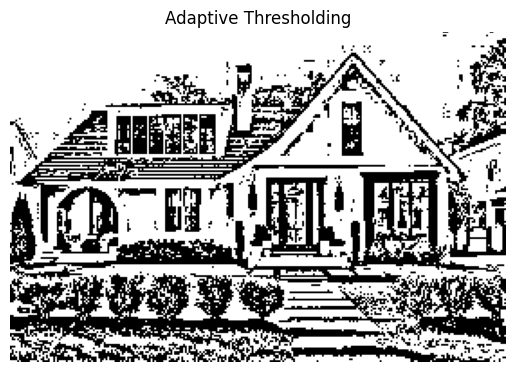

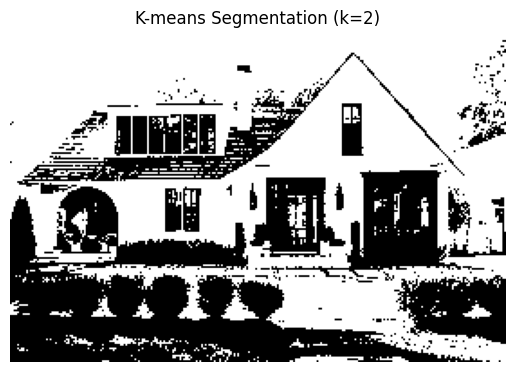

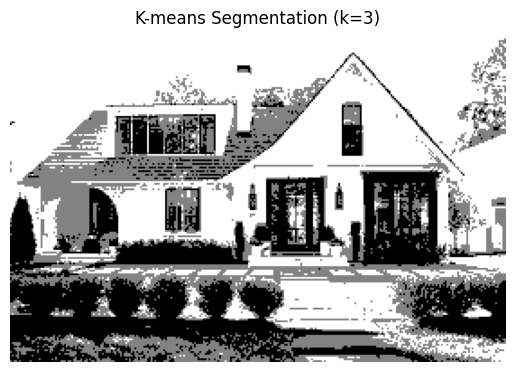

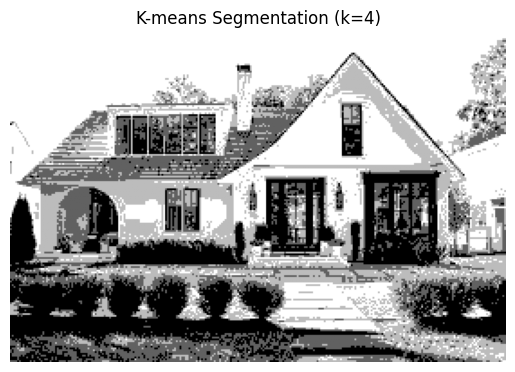

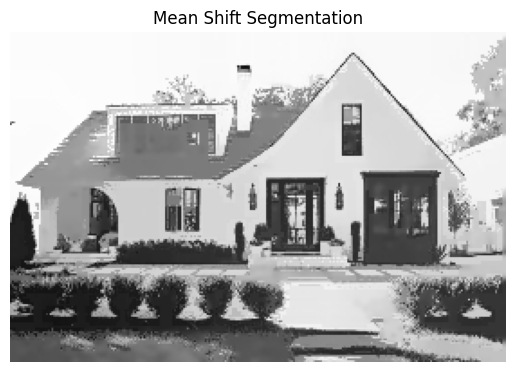

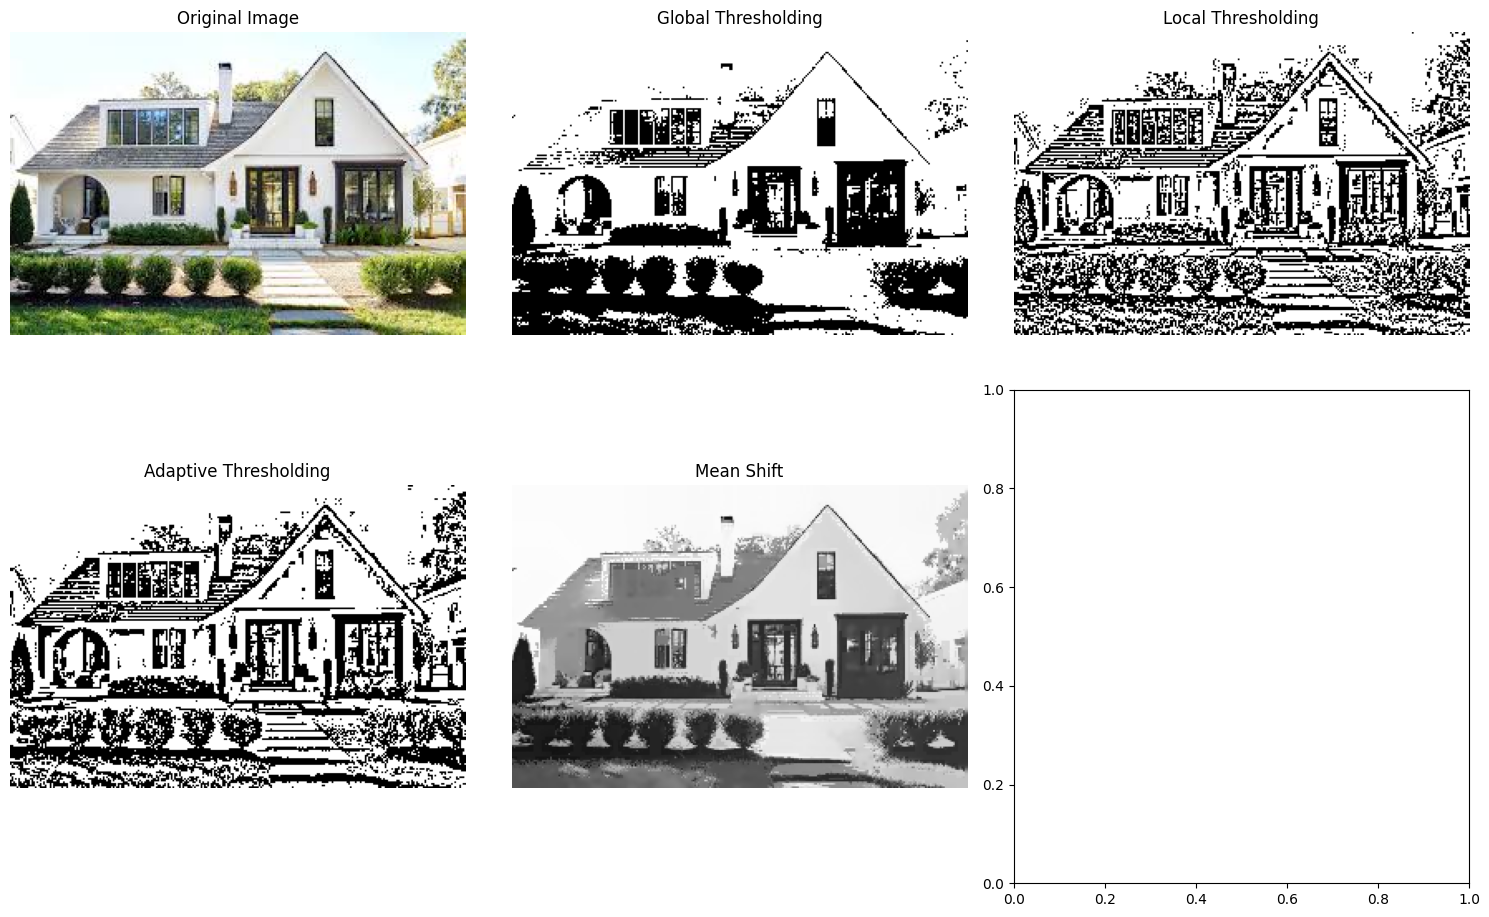


1. Global Thresholding:
   - Simple and effective for images with uniform lighting.

2. Local Thresholding:
   - Works well for varying illumination and highlights features better.

3. K-means Segmentation:
   - Clusters pixels based on color similarity, but sensitive to initialization.

4. Mean Shift Segmentation:
   - Non-parametric and does not require preprocessing, adapts to the pixel distribution.



In [12]:

# Function to display images
def display_image(image, title='Image'):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) if len(image.shape) == 3 else plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Load the image
# Replace 'path/to/your/image.jpg' with your actual image path in Google Drive
image_path = '/content/task_12_a.jfif'
image = cv2.imread(image_path)

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
display_image(gray_image, title='Grayscale Image')

# Task 1: Global Thresholding
_, global_thresh = cv2.threshold(gray_image, 128, 255, cv2.THRESH_BINARY)
display_image(global_thresh, title='Global Thresholding')

# Task 1: Local Thresholding (using adaptive thresholding)
local_thresh = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)
display_image(local_thresh, title='Local Thresholding')

# Task 1: Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                         cv2.THRESH_BINARY, 11, 2)
display_image(adaptive_thresh, title='Adaptive Thresholding')

# Task 2: K-means Segmentation
def kmeans_segmentation(image, k):
    # Reshape the image to a 2D array of pixels
    pixel_values = image.reshape((-1, 1))
    pixel_values = np.float32(pixel_values)

    # Define criteria and apply k-means
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Convert back to uint8 and reshape to original image dimensions
    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    return segmented_image.reshape(image.shape)

# Perform K-means segmentation with k=2, k=3, k=4
for k in [2, 3, 4]:
    kmeans_result = kmeans_segmentation(gray_image, k)
    display_image(kmeans_result, title=f'K-means Segmentation (k={k})')

# Task 3: Mean Shift Segmentation
def mean_shift_segmentation(image):
    # Convert to a 2D array of pixel values
    pixel_values = image.reshape((-1, 1))
    pixel_values = np.float32(pixel_values)

    # Apply Mean Shift. The function expects a 3-channel image.
    # Convert the 1-channel grayscale image to a 3-channel BGR image.
    bgr_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    mean_shift = cv2.pyrMeanShiftFiltering(bgr_image, sp=21, sr=51)
    return mean_shift

mean_shift_result = mean_shift_segmentation(gray_image)
display_image(mean_shift_result, title='Mean Shift Segmentation')

# Task 4: Compare Results Visually
titles = ['Original Image', 'Global Thresholding', 'Local Thresholding',
          'Adaptive Thresholding', 'Mean Shift']
images = [image, global_thresh, local_thresh, adaptive_thresh, mean_shift_result]

# Display comparisons
comparison_fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for ax, title, img in zip(axs.ravel(), titles, images):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape) == 3 else img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Task 5: Discuss Method Strengths
discussion = """
1. Global Thresholding:
   - Simple and effective for images with uniform lighting.

2. Local Thresholding:
   - Works well for varying illumination and highlights features better.

3. K-means Segmentation:
   - Clusters pixels based on color similarity, but sensitive to initialization.

4. Mean Shift Segmentation:
   - Non-parametric and does not require preprocessing, adapts to the pixel distribution.
"""

print(discussion)